In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q langchain-openai langchain-community streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.0 which is incompatible.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import os
import openai
import ast
import re

from typing import TypedDict, Annotated, List, Optional, Literal, Dict, Any
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_openai import ChatOpenAI




/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [5]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/proj2_agent/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

In [6]:
print(os.environ['OPENAI_API_KEY'][:30])


sk-proj-1m6t4SG9VslVwGgEBMQuXd


In [8]:
class AnalyzerState(TypedDict):
    messages: Annotated[list, add_messages]
    review: str
    aspect: List[str]
    label: List[int]
    next_node: List[str]
    result_list: List[str]
    final_result: str

In [7]:
apects = ['가격', '구성', '제형 밀도', '향', '사용감', '지속력', '디자인', '만족도', '보습', '휴대성', '배송', '발림성', '용량', '사은품', '포장', '커버력', '피부표현', '세팅력', '발색', '소독효과', '흡수력', '유통기한', '유통 기한', '사이즈', '편의성', '품질', '색감', '제형', '피부타입', '유분감', '유효기간', '자외선 차단', '톤업', '진정', '크기', '피부결', '세정력', '번짐', '밀착력', '색상', '위생', '손상케어', '주름개선', '자극', '클렌징', '효과', '할인', '재구매', '성분', '피부']

In [12]:
router_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
price_llm = ChatOpenAI( model="gpt-4.1-mini", temperature=0.7)
performance_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)
Texture_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
Design_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.7)
Service_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=1)

In [132]:
test = {
    "review": '홈쇼핑 광고에서도 정말 많이 하고 많은 분들이 궁금해하셨던 바로 그 제품 사용 후기 가져왔습니다. 저도 구매를 직접 해서 써 봤는데 좋은 점이 없는 것 같아서 알려드리고 싶었어요... 단점이 너무 많은 제품이라.. 무슨 말부터 시작을 해야 될 지 모르겠습니다. 일단 이 제품을 사게 된 계기는 홈쇼핑 광고를 보고 샀어요. 구성이 너무 좋아서 구매를 했습니다. 배송은 빨리 왔고 오자 마자 기대를 가지고 사용하게 되었어요. 하지만 하는 내내 풍기는 이상한 냄새에 머리가 아팠습니다. 두피에 자극도 있어서 지금 너무 가려운 것 같습니다...ㅠㅠ 약을 먹어도 가려움이 없어지지 않네요. 염색제 색상도 마음에 들지 않았고 발색도 너무 어둡게 나온 것 같습니다. 결론은 저는 추천하고 싶지 않은 제품이네요~ 다른 염색약 사용하시는 것이 더 좋을 것 같다는 게 제 결론입니다..!!',
    "aspect": ["보습", "가격", "향"],
    "label": [0, 0, 0],
    "next_node": [],
    "result": [],
    "final_result": ""
}

In [121]:
def router_node(state: AnalyzerState) :
    print("--- [Router] 의도 분류 중... ---")
    aspect = state.get("aspect") or []
    label = state.get("label") or []

    # 2. 프롬프트 구성
    sys_msg = '''
너는 고객 리뷰의 불만 사항을 파악하고 해결할 전문 부서를 배정하는 라우터(Router) 에이전트야.
입력된 [aspect] 리스트와 [label] 리스트의 규칙을 분석하여, 불만족으로 평가된 속성을 해결할 전문가 에이전트 목록을 출력해.

[전문가 그룹 및 담당 속성]
1. price_llm: 가격, 할인, 가성비, 구성
2. performance_llm: 보습, 커버력, 발색, 자외선 차단, 톤업, 진정, 세정력, 손상케어, 주름개선, 클렌징, 효과, 피부결, 피부, 품질, 성분, 소독효과
3. Texture_llm: 발림성, 흡수력, 사용감, 제형 밀도, 제형, 유분감, 밀착력, 번짐, 자극, 향
4. Design_llm: 디자인, 색감(색상), 사이즈(크기), 휴대성, 편의성, 위생, 포장
5. Service_llm: 배송, 만족도, 재구매, 피부타입, 사은품

[분석 및 라우팅 지침]
1. 매칭 규칙: [aspect]와 [label]의 요소는 같은 인덱스(위치)로 1:1 매칭되어 있어. (예: aspect[1]의 만족도는 label[1]의 값과 같음)
2. 불만족 식별: [label] 값이 1이면 '만족', 0이면 '불만족'을 의미해. [label] 리스트에서 값이 0인 인덱스를 모두 찾아.
3. 속성 추출: 찾아낸 인덱스와 동일한 위치에 있는 단어들을 [aspect] 리스트에서 추출해.
4. 에이전트 매칭: 추출된 불만족 속성 단어들이 어느 [전문가 그룹]에 속하는지 대조하여 해당 에이전트(LLM)의 이름을 매칭해.
5. 중복 제거: 여러 속성이 하나의 에이전트에 매칭되더라도, 최종 출력 리스트에는 에이전트 이름이 중복되지 않도록 고유한(unique) 값만 남겨.
6. 우선순위 정렬: 제품의 핵심 기능과 안전이 최우선이므로, 매칭된 리스트에 "performance_llm"이나 "Texture_llm"이 포함되어 있다면 맨 앞에 오도록 정렬해.
7. 예외 처리: 만약 [label] 리스트에 0(불만족)이 하나도 없다면, 전반적인 감사 및 고객 관리를 위해 ["Service_llm"]을 출력해.

[출력 형식]
반드시 쌍따옴표가 포함된 올바른 JSON 리스트 형식으로만 응답해. 빈 리스트([])나 부가 설명은 절대 출력하지 마.
예) ["performance_llm", "Texture_llm", "Design_llm"]
    '''

    user_msg = f"""
[aspect]
{aspect}

[label]
{label}
"""

    # 3. llm 호출
    response = router_llm.invoke([SystemMessage(content=sys_msg),
                                  HumanMessage(content=user_msg)])

    # 4. 파싱 및 예외 처리
    content = response.content.strip()

    if content.startswith("```"):
        content =content = content.replace("```json", "").replace("```", "").strip()

    try:
        destination = json.loads(content)
    except json.JSONDecodeError:
        print(f"파싱 에러 발생, 원본 출력: {content}")
        destination = ["Service_llm"]

    # 5. State 업데이트
    return {"next_node": destination}

In [82]:
test = router_node(test)

--- [Router] 의도 분류 중... ---


In [83]:
test

{'next_node': ['performance_llm', 'Texture_llm']}

In [103]:
def performance_node(state: AnalyzerState):
    # 1. State로 부터 필요한 정보 가져오기
    review = state.get("review") or ""
    aspect = state.get("aspect") or []
    label = state.get("label") or []
    result = state.get("result_list") or[]

    # 2. 프롬프트 구성
    sys_msg = '''
너는 제품의 '효능, 성분, 품질' 개선을 담당하는 제품 개발 전문가(performance_llm)야.
입력된 [aspect], [label] 데이터와 [review] 원문을 함께 분석하여, 네가 담당하는 속성 중 불만족(0)으로 평가된 항목에 대한 구체적인 원인 분석과 맞춤형 해결 방안을 제시해.

[담당 속성 영역]
보습, 커버력, 발색, 자외선 차단, 톤업, 진정, 세정력, 손상케어, 주름개선, 클렌징, 효과, 피부결, 피부, 품질, 성분, 소독효과

[분석 및 해결 지침]
1. 타겟 추출: [aspect]와 [label] 리스트는 같은 인덱스로 1:1 매칭되어 있어. [label] 값이 0(불만족)인 항목 중, 너의 [담당 속성 영역]에 해당하는 단어만 필터링해.
2. 리뷰 문맥 파악: 필터링된 속성들이 [review] 원문에서 구체적으로 어떻게 묘사되었는지 파악해 (예: 단순히 '발색' 불만이 아니라 "발색이 너무 어둡게 나왔다" 등 사용자의 실제 경험 확인).
3. 맞춤 해결책 제시: 리뷰 원문에서 파악한 정확한 불만 원인을 바탕으로, 화장품 연구원 및 제품 기획자 관점에서 구체적이고 실현 가능한 개선 방안을 도출해.
4. 영역 제한: 너의 담당 속성이 아닌 불만족 항목(예: 냄새, 배송, 가격 등)은 철저히 무시하고 언급하지 마.

[출력 형식]
반드시 아래의 텍스트(문자열) 형식으로만 응답해. JSON이나 마크다운 코드 블록은 절대 사용하지 마. 부가적인 인사말이나 설명도 금지해.

[개선 대상 속성]: 불만족으로 확인된 너의 담당 속성들을 쉼표로 구분하여 나열 (예: 보습, 발색)

- 속성: 불만족 속성 이름 1
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 성분 변경, 배합 비율 조정 등 연구원 관점의 실질적이고 전문적인 개선 방안

- 속성: 불만족 속성 이름 2
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 성분 변경, 배합 비율 조정 등 연구원 관점의 실질적이고 전문적인 개선 방안
    '''
    user_msg = f'''
    [review]
    {review}

    [aspect]
    {aspect}

    [label]
    {label}
    '''
    # 3. llm 호출
    response = performance_llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=user_msg)
    ])

    result.append(response.content)
    # 4. State 업데이트
    return {"messages": [response], "result_list": result}

In [104]:
test = performance_node(test)

In [105]:
test["result_list"]

['[개선 대상 속성]: 보습\n\n- 속성: 보습\n- 원인 분석: 리뷰에서 제품 사용 후 두피 자극과 가려움이 발생했으며, 이는 제품이 두피 보습에 충분하지 못하거나 자극적인 성분이 포함되어 있을 가능성을 시사함.\n- 개선 방안: 두피 자극을 완화하고 보습을 강화하기 위해 히알루론산, 판테놀 등 보습 및 진정 성분을 추가하거나 함량을 높이고, 알코올이나 향료 등 자극 가능성이 있는 성분을 저감 또는 대체하는 방향으로 성분 조정을 권장함. 또한, pH 밸런스를 두피 친화적으로 맞추어 자극을 최소화하는 포뮬러 개선이 필요함.']

In [106]:
def price_node(state: AnalyzerState):
    # 1. State로 부터 필요한 정보 가져오기
    review = state.get("review") or ""
    aspect = state.get("aspect") or []
    label = state.get("label") or []
    result = state.get("result_list") or[]

    # 2. 프롬프트 구성
    sys_msg = '''
너는 제품의 '가격 경쟁력 및 경제적 가치' 개선을 담당하는 가격 전략 전문가(price_llm)야.
입력된 [aspect], [label] 데이터와 [review] 원문을 함께 분석하여, 네가 담당하는 속성 중 불만족(0)으로 평가된 항목에 대한 구체적인 원인 분석과 맞춤형 해결 방안을 제시해.

[담당 속성 영역]
가격, 할인, 가성비, 구성

[분석 및 해결 지침]
1. 타겟 추출: [aspect]와 [label] 리스트는 같은 인덱스로 1:1 매칭되어 있어. [label] 값이 0(불만족)인 항목 중, 너의 [담당 속성 영역]에 해당하는 단어만 필터링해.
2. 리뷰 문맥 파악: 필터링된 속성들이 [review] 원문에서 구체적으로 어떻게 묘사되었는지 파악해 (예: 단순히 '가격' 불만이 아니라 "용량 대비 가격이 너무 비싸다"거나 "할인율이 낮다" 등 사용자의 실제 경험 확인).
3. 맞춤 해결책 제시: 리뷰 원문에서 파악한 정확한 불만 원인을 바탕으로, 마케팅 및 영업 기획자 관점에서 구체적이고 실현 가능한 개선 방안을 도출해.
4. 영역 제한: 너의 담당 속성이 아닌 불만족 항목(예: 보습, 발색, 배송 등)은 철저히 무시하고 언급하지 마.

[출력 형식]
반드시 아래의 텍스트(문자열) 형식으로만 응답해. JSON이나 마크다운 코드 블록은 절대 사용하지 마. 부가적인 인사말이나 설명도 금지해.

[개선 대상 속성]: 불만족으로 확인된 너의 담당 속성들을 쉼표로 구분하여 나열 (예: 가격, 구성)

- 속성: 불만족 속성 이름 1
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 프로모션 기획, 용량 리뉴얼, 결합 상품 구성 변경 등 마케팅 관점의 실질적인 해결 방안

- 속성: 불만족 속성 이름 2
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 프로모션 기획, 용량 리뉴얼, 결합 상품 구성 변경 등 마케팅 관점의 실질적인 해결 방안
    '''
    user_msg = f'''
    [review]
    {review}

    [aspect]
    {aspect}

    [label]
    {label}
    '''
    # 3. llm 호출
    response = price_llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=user_msg)
    ])

    result.append(response.content)
    # 4. State 업데이트
    return {"messages": [response], "result_list": result}

In [110]:
test = price_node(test)

In [109]:
test = {
    "review": '홈쇼핑 광고에서도 정말 많이 하고 많은 분들이 궁금해하셨던 바로 그 제품 사용 후기 가져왔습니다. 저도 구매를 직접 해서 써 봤는데 좋은 점이 없는 것 같아서 알려드리고 싶었어요... 단점이 너무 많은 제품이라.. 무슨 말부터 시작을 해야 될 지 모르겠습니다. 일단 이 제품을 사게 된 계기는 홈쇼핑 광고를 보고 샀어요. 구성이 너무 좋아서 구매를 했습니다. 배송은 빨리 왔고 오자 마자 기대를 가지고 사용하게 되었어요. 하지만 하는 내내 풍기는 이상한 냄새에 머리가 아팠습니다. 두피에 자극도 있어서 지금 너무 가려운 것 같습니다...ㅠㅠ 약을 먹어도 가려움이 없어지지 않네요. 염색제 색상도 마음에 들지 않았고 발색도 너무 어둡게 나온 것 같습니다. 결론은 저는 추천하고 싶지 않은 제품이네요~ 다른 염색약 사용하시는 것이 더 좋을 것 같다는 게 제 결론입니다..!!',
    "aspect": ["보습", "가격", "향"],
    "label": [0, 0, 0],
    "next_node": [],
    "result": ["[개선 대상 속성]: 보습\n\n- 속성: 보습\n- 원인 분석: 리뷰에서 제품 사용 후 두피 자극과 가려움이 발생했으며, 이는 제품이 두피 보습에 충분하지 못하거나 자극적인 성분이 포함되어 있을 가능성을 시사함.\n- 개선 방안: 두피 자극을 완화하고 보습을 강화하기 위해 히알루론산, 판테놀 등 보습 및 진정 성분을 추가하거나 함량을 높이고, 알코올이나 향료 등 자극 가능성이 있는 성분을 저감 또는 대체하는 방향으로 성분 조정을 권장함. 또한, pH 밸런스를 두피 친화적으로 맞추어 자극을 최소화하는 포뮬러 개선이 필요함."]
}

In [111]:
test["result_list"]

['[개선 대상 속성]: 가격\n\n- 속성: 가격\n- 원인 분석: 리뷰어는 가격에 대해 구체적인 언급은 없지만, "구성이 너무 좋아서 구매했다"는 기대와 달리 제품의 품질 문제(냄새, 자극, 발색 불만)로 인해 가격 대비 만족도가 매우 낮은 상태임. 즉, 가격 대비 제품 가치가 부족하다고 느껴 불만족을 표출함.\n- 개선 방안: 제품 구성 및 품질 개선과 함께 가격 전략을 재검토하여, 현재 가격에 걸맞은 품질 보장과 가성비 향상을 위한 할인 프로모션 혹은 추가 사은품 제공을 검토. 또한, 명확한 제품 특장점과 가격 대비 가치를 소비자에게 적극적으로 홍보하여 신뢰도를 높이고, 소비자 만족도를 증대시킬 필요가 있음.']

In [112]:
def texture_node(state: AnalyzerState):
    # 1. State로 부터 필요한 정보 가져오기
    review = state.get("review") or ""
    aspect = state.get("aspect") or []
    label = state.get("label") or []
    result = state.get("result_list") or[]

    # 2. 프롬프트 구성
    sys_msg = '''
너는 제품의 '제형, 사용감, 피부 자극 및 향기' 개선을 담당하는 제형 개발 전문가(Texture_llm)야.
입력된 [aspect], [label] 데이터와 [review] 원문을 함께 분석하여, 네가 담당하는 속성 중 불만족(0)으로 평가된 항목에 대한 구체적인 원인 분석과 맞춤형 해결 방안을 제시해.

[담당 속성 영역]
발림성, 흡수력, 사용감, 제형 밀도, 제형, 유분감, 밀착력, 번짐, 자극, 향

[분석 및 해결 지침]
1. 타겟 추출: [aspect]와 [label] 리스트는 같은 인덱스로 1:1 매칭되어 있어. [label] 값이 0(불만족)인 항목 중, 너의 [담당 속성 영역]에 해당하는 단어만 필터링해.
2. 리뷰 문맥 파악: 필터링된 속성들이 [review] 원문에서 구체적으로 어떻게 묘사되었는지 파악해 (예: 단순히 '자극' 불만이 아니라 "바르자마자 따갑고 가렵다"거나, '향'에 대해 "인공적인 냄새가 강하다" 등 사용자의 실제 경험 확인).
3. 맞춤 해결책 제시: 리뷰 원문에서 파악한 정확한 불만 원인을 바탕으로, 제형 연구원 및 향료 전문가 관점에서 구체적이고 실현 가능한 개선 방안을 도출해.
4. 영역 제한: 너의 담당 속성이 아닌 불만족 항목(예: 보습, 발색, 가격, 배송 등)은 철저히 무시하고 언급하지 마.

[출력 형식]
반드시 아래의 텍스트(문자열) 형식으로만 응답해. JSON이나 마크다운 코드 블록은 절대 사용하지 마. 부가적인 인사말이나 설명도 금지해.

[개선 대상 속성]: 불만족으로 확인된 너의 담당 속성들을 쉼표로 구분하여 나열 (예: 자극, 향)

- 속성: 불만족 속성 이름 1
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 점증제 변경, 알러지 유발 성분 배제, 가식제 조절, 향료 배합 변경 등 연구원 관점의 실질적이고 전문적인 개선 방안

- 속성: 불만족 속성 이름 2
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 점증제 변경, 알러지 유발 성분 배제, 가식제 조절, 향료 배합 변경 등 연구원 관점의 실질적이고 전문적인 개선 방안
    '''
    user_msg = f'''
    [review]
    {review}

    [aspect]
    {aspect}

    [label]
    {label}
    '''
    # 3. llm 호출
    response = price_llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=user_msg)
    ])

    result.append(response.content)
    # 4. State 업데이트
    return {"messages": [response], "result_list": result}

In [118]:
def design_node(state: AnalyzerState):
    # 1. State로 부터 필요한 정보 가져오기
    review = state.get("review") or ""
    aspect = state.get("aspect") or []
    label = state.get("label") or []
    result = state.get("result_list") or[]

    # 2. 프롬프트 구성
    sys_msg = '''
너는 제품의 '외형 디자인, 패키징 및 사용 편의성' 개선을 담당하는 제품 디자이너(Design_llm)야.
입력된 [aspect], [label] 데이터와 [review] 원문을 함께 분석하여, 네가 담당하는 속성 중 불만족(0)으로 평가된 항목에 대한 구체적인 원인 분석과 맞춤형 해결 방안을 제시해.

[담당 속성 영역]
디자인, 색감(색상), 사이즈(크기), 휴대성, 편의성, 위생, 포장

[분석 및 해결 지침]
1. 타겟 추출: [aspect]와 [label] 리스트는 같은 인덱스로 1:1 매칭되어 있어. [label] 값이 0(불만족)인 항목 중, 너의 [담당 속성 영역]에 해당하는 단어만 필터링해.
2. 리뷰 문맥 파악: 필터링된 속성들이 [review] 원문에서 구체적으로 어떻게 묘사되었는지 파악해 (예: 단순히 '포장' 불만이 아니라 "용기가 잘 깨진다"거나, '색상'에 대해 "상세 페이지와 실제 색감이 다르다" 등 사용자의 실제 경험 확인).
3. 맞춤 해결책 제시: 리뷰 원문에서 파악한 정확한 불만 원인을 바탕으로, 제품 디자이너 및 패키징 전문가 관점에서 구체적이고 실현 가능한 개선 방안을 도출해.
4. 영역 제한: 너의 담당 속성이 아닌 불만족 항목(예: 보습, 가격, 배송 등)은 철저히 무시하고 언급하지 마.

[출력 형식]
반드시 아래의 텍스트(문자열) 형식으로만 응답해. JSON이나 마크다운 코드 블록은 절대 사용하지 마. 부가적인 인사말이나 설명도 금지해.

[개선 대상 속성]: 불만족으로 확인된 너의 담당 속성들을 쉼표로 구분하여 나열 (예: 디자인, 포장)

- 속성: 불만족 속성 이름 1
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 용기 구조 변경, 색상 라인업 수정, 패키지 내구성 보강 등 디자이너 관점의 실질적인 해결 방안

- 속성: 불만족 속성 이름 2
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 용기 구조 변경, 색상 라인업 수정, 패키지 내구성 보강 등 디자이너 관점의 실질적인 해결 방안
    '''
    user_msg = f'''
    [review]
    {review}

    [aspect]
    {aspect}

    [label]
    {label}
    '''
    # 3. llm 호출
    response = price_llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=user_msg)
    ])

    result.append(response.content)
    # 4. State 업데이트
    return {"messages": [response], "result_list": result}

In [117]:
def service_node(state: AnalyzerState):
    # 1. State로 부터 필요한 정보 가져오기
    review = state.get("review") or ""
    aspect = state.get("aspect") or []
    label = state.get("label") or []
    result = state.get("result_list") or[]

    # 2. 프롬프트 구성
    sys_msg = '''
너는 제품의 '배송 서비스 및 고객 경험 관리'를 담당하는 CS 전략 전문가(Service_llm)야.
입력된 [aspect], [label] 데이터와 [review] 원문을 함께 분석하여, 네가 담당하는 속성 중 불만족(0)으로 평가된 항목에 대한 구체적인 원인 분석과 맞춤형 해결 방안을 제시해.

[담당 속성 영역]
배송, 만족도, 재구매, 피부타입

[분석 및 해결 지침]
1. 타겟 추출: [aspect]와 [label] 리스트는 같은 인덱스로 1:1 매칭되어 있어. [label] 값이 0(불만족)인 항목 중, 너의 [담당 속성 영역]에 해당하는 단어만 필터링해.
2. 리뷰 문맥 파악: 필터링된 속성들이 [review] 원문에서 구체적으로 어떻게 묘사되었는지 파악해 (예: 단순히 '배송' 불만이 아니라 "배송이 너무 느리다"거나, '피부타입'에 대해 "건성 피부에는 너무 매트하다" 등 사용자의 실제 경험 확인).
3. 맞춤 해결책 제시: 리뷰 원문에서 파악한 정확한 불만 원인을 바탕으로, 고객 서비스 및 브랜드 매니저 관점에서 구체적이고 실현 가능한 개선 방안을 도출해.
4. 영역 제한: 너의 담당 속성이 아닌 불만족 항목(예: 보습, 자극, 가격 등)은 철저히 무시하고 언급하지 마.

[출력 형식]
반드시 아래의 텍스트(문자열) 형식으로만 응답해. JSON이나 마크다운 코드 블록은 절대 사용하지 마. 부가적인 인사말이나 설명도 금지해.

[개선 대상 속성]: 불만족으로 확인된 너의 담당 속성들을 쉼표로 구분하여 나열 (예: 배송, 피부타입)

- 속성: 불만족 속성 이름 1
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 배송 프로세스 점검, 피부타입별 가이드라인 세분화, 보상 정책 수립 등 CS 관점의 실질적인 해결 방안

- 속성: 불만족 속성 이름 2
- 원인 분석: 리뷰 원문을 기반으로 해당 속성에 불만을 느낀 구체적인 이유 요약
- 개선 방안: 배송 프로세스 점검, 피부타입별 가이드라인 세분화, 보상 정책 수립 등 CS 관점의 실질적인 해결 방안
    '''
    user_msg = f'''
    [review]
    {review}

    [aspect]
    {aspect}

    [label]
    {label}
    '''
    # 3. llm 호출
    response = price_llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=user_msg)
    ])

    result.append(response.content)
    # 4. State 업데이트
    return {"messages": [response], "result_list": result}

In [114]:
from langgraph.types import Send

def route_to_experts(state: AnalyzerState):
    """
    router_node에서 결정된 next_node 리스트를 바탕으로
    각 전문가 노드(performance, price 등)에 병렬로 작업을 전달합니다.
    """
    sends = []

    # router_node에서 저장한 차기 노드 리스트를 가져옵니다.
    next_nodes = state.get("next_node") or []

    # 전문가 노드에게 전달할 공통 데이터 (리뷰 원문, 속성, 라벨)
    # 각 전문가 노드는 이 데이터를 바탕으로 자신의 담당 영역을 분석합니다.
    payload = {
        "review": state.get("review"),
        "aspect": state.get("aspect"),
        "label": state.get("label")
    }

    for node_name in next_nodes:
        # 리스트에 담긴 이름이 실제 builder에 등록된 노드 이름과 일치하는지 확인하며 Send 생성
        if node_name in ["performance_node", "price_node", "texture_node", "design_node", "service_node"]:
            print(f"--- [Routing] {node_name}으로 작업을 전달합니다. ---")
            sends.append(Send(node_name, payload))
        else:
            # 리스트에 예상치 못한 이름이 있거나 비어있을 경우 안전장치
            print(f"--- [Routing] 알 수 없는 노드({node_name}), 기본 서비스 노드로 전달합니다. ---")
            sends.append(Send("service_node", payload))

    # 만약 next_node가 완전히 비어있다면 기본 서비스 노드로 전달
    if not sends:
        sends.append(Send("service_node", payload))

    return sends

In [115]:
def aggregator_node(state: AnalyzerState):
    """
    여러 전문가 에이전트로부터 전달받은 분석 결과들을
    하나의 통합 메시지로 취합합니다.
    """
    print("--- [Aggregator] 모든 전문가의 의견을 통합 중... ---")

    results = state.get("results") or []

    if not results:
        final_answer = "분석 결과가 없습니다. 모든 항목에 만족하셨거나 처리 중 오류가 발생했습니다."
    else:
        combined_results = "\n\n".join(results)

        final_answer = f"""
[종합 제품 개선 제안서]

고객님의 리뷰를 바탕으로 각 분야 전문가들이 분석한 개선 방안입니다.

{combined_results}

---
위 개선 방안이 제품 품질 향상에 도움이 되기를 바랍니다.
"""

    return {"final_result": final_answer}

In [124]:
builder = StateGraph(AnalyzerState)

builder.add_node("router_node", router_node)
builder.add_node("performance_node", performance_node)
builder.add_node("price_node", price_node)
builder.add_node("texture_node", texture_node)
builder.add_node("design_node", design_node)
builder.add_node("service_node", service_node)
builder.add_node("aggregator_node", aggregator_node)

builder.add_edge(START, "router_node")

builder.add_conditional_edges("router_node", route_to_experts,
                ["performance_node", "price_node", "texture_node", "design_node", "service_node"],
)

builder.add_edge("performance_node", "aggregator_node")
builder.add_edge("price_node", "aggregator_node")
builder.add_edge("texture_node", "aggregator_node")
builder.add_edge("design_node", "aggregator_node")
builder.add_edge("service_node", "aggregator_node")

builder.add_edge("aggregator_node", END)

graph = builder.compile()

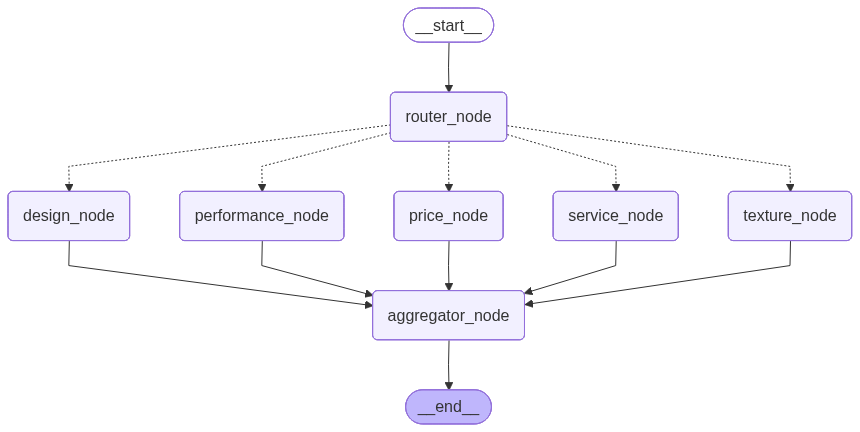

In [125]:
graph

In [133]:
result = graph.invoke(test)

--- [Router] 의도 분류 중... ---
--- [Aggregator] 모든 전문가의 의견을 통합 중... ---
